In [1]:
from __future__ import annotations
from pathlib import Path
import dataretrieval.nwis as nwis
import dataretrieval.waterdata as waterdata
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynhd as nhd
from pynhd import NLDI, WaterData
import pygeohydro as gh
import xarray as xr
import os
from scripts import maps, data, dataprocessing, SNOTEL_Analyzer, files, catchment, stream_analysis,SWE_Stream


In [2]:
#Initialize names and parameters

nldi = NLDI()
station = '09114500' #GUNNISON RIVER above blue mesa reservoir
WY = 2025 #2025 water year ends on oct 1 2025, so the DOI falles within this water year

basin = nldi.get_basins(station)
basinname = 'BlueMesaReservoir'
geometry = basin.geometry.iloc[0]
watershed = "Upper Gunnison"
AOI = 'Above Blue Mesa Reservoir'
DOI = '04-01'

## Make data files

This next code blocks will create the basic file framework for the rest of the project. It utilizes open resources such as USGS to obtain the data frames. 

In [12]:
#Basin File
site_feature, upstream_network = files.basinFile(basin, basinname, station)

done


In [3]:
#SNOTEL File
snotel = files.snotelFile(geometry,'CO')

Start retrieving data for Butte, 380_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/380:CO:SNTL%7Cid=%22%22%7Cname/1979-10-01,2026-03-31/WTEQ::value?fitToScreen=false
Start retrieving data for Park Cone, 680_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/680:CO:SNTL%7Cid=%22%22%7Cname/1979-10-01,2026-03-31/WTEQ::value?fitToScreen=false
Start retrieving data for Upper Taylor, 1141_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/1141:CO:SNTL%7Cid=%22%22%7Cname/2009-08-26,2026-03-31/WTEQ::value?fitToScreen=false


In [14]:
#Streamflow File
discharge = files.dischargeFile(station)

Retrieving data for Site: 09114500 from 1980-01-01 to 2025-10-01...


<div style="height:100px;"></div>

# 2. SWE Analysis for Snotel 

### Sites descriptions 

The following gives an overview of the snotel stations. In summary, the stations can each be described with:

 <u> Butte:</u>

Location: (38.894329,-106.953003)
Elevation: 3096.8 m 
Length of Operations: 1979-10-01 - present

<u> Park Cone:</u>

Location: (38.819962,-106.58973)
Elevation: 2926.1 m 
Length of Operations: 1979-10-01 - present

<u> Upper Taylor:</u>

Location: (38.99076,-106.7542)
Elevation: 3243.1 m 
Length of Operations: 2009-08-26 - present

From these, we see that Upper Taylor may not give as helpful of a historical analysis, but there is possibility that it will help present analysis. However, it will be clear in later cells that this was not the case

In [25]:
snotel.T

,0,1,2
code,380_CO_SNTL,680_CO_SNTL,1141_CO_SNTL
name,Butte,Park Cone,Upper Taylor
network,SNOTEL,SNOTEL,SNOTEL
elevation_m,3096.768066,2926.080078,3243.072021
latitude,38.894329,38.819962,38.990768
longitude,-106.953003,-106.589737,-106.754219
state,Colorado,Colorado,Colorado
HUC,140200010206,140200010107,140200010101
mgrs,13SCD,13SCC,13SCD
mountainRange,Southern Rocky Mountains,Southern Rocky Mountains,Southern Rocky Mountains


### Historical Comparison

The next cell will load all three sites into one dataframe, and process it to be able to show key lines for historical analysis. 

In [4]:

# Load the data for one site
sites = list(snotel.code)
print(sites)
stateab = 'Co'
sitedict = dict()

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab, WY)

['380_CO_SNTL', '680_CO_SNTL', '1141_CO_SNTL']
380_CO_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
680_CO_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
1141_CO_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site


Below are the historical analysis plots for each individual SNOTEL site. This is analyzed more in depth in the report. However, as a brief summary, there are some key points to note. First, Park Cone does not ahve any data outside of October-November. However, as seen in the other plots, the later months are essentail to observe snow decrease into spring, as it is not an exact reflectance of the earlier months. In addition, the Butte SNOTEL site seems to have the largest distribution with peak flow, but has the most consistent bell shape. In fact, our targeted water year of 2025 nearly perfectly matches the SWE median at this site. For the Upper Taylor site, the 2025 is also pretty consistent, but also jumps past the peak flow in the earlier months. Upper Taylor also has the noisiest peak and steepest drop at the later months. This likely indicates that this site is more sensative to the warming of spring. 

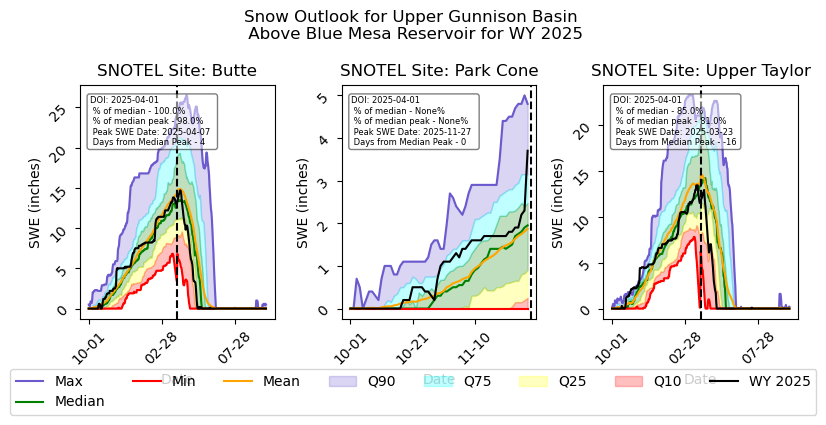

In [27]:
SNOTEL_Analyzer.SNOTELPlots(sitedict,snotel,WY,watershed,AOI, DOI)

The sites were then averages and combined so the entire catchment can be observed for Historical SWE, which is discussed in the report. As a summary, it should be noted that 2025 appears to experience an average SWE. While the target date is slightly below average, this SWE would still indicate that 2025 was a typical year. Because it is typical, water in later ecosystems is expected to also be relatively typical. This will be further analyzed when looking at streamflow. 

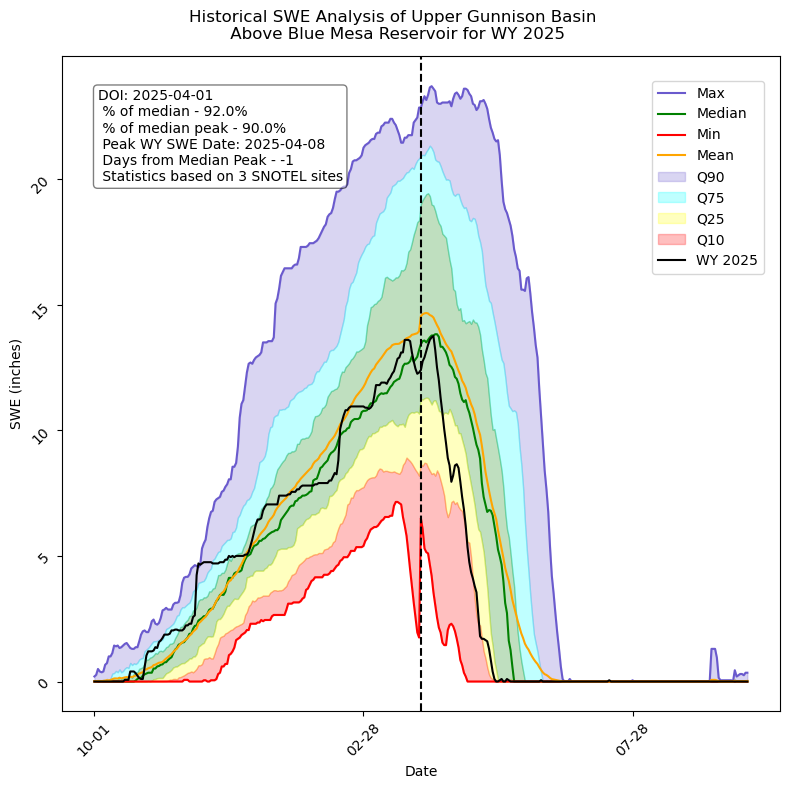

In [5]:
catchmentswe = SNOTEL_Analyzer.catchmentSNOTELAnalysis(sitedict, WY, watershed, AOI, DOI)

<div style="height:100px;"></div>

# 3. Streamflow Analysis

### Location Information 

This next block will show the generalized information for this catchment. In addition to waht is below, some data was pulled directly from the website "https://waterdata.usgs.gov/monitoring-location/USGS-09114500/#dataTypeId=continuous-00065-0&period=P7D&showFieldMeasurements=true" Since we only had one stream gauge in the basin, this can be easily summarized as: 

location: (-106.9497661258 38.5419356710082)
Watershed: Upper Gunnison
Elevation: 7659.9 ft
Length of Operation: 1910-10-01 - Present 
Other: Stream-type, Parameter code 00060 (Daily Discharge)

In [ ]:
info, met = waterdata.get_monitoring_locations(monitoring_location_id= f"USGS-{station}")
info = info.T.dropna()
info.head(50)

,0
monitoring_location_id,USGS-09114500
geometry,POINT (-106.9497661258 38.5419356710082)
agency_code,USGS
agency_name,U.S. Geological Survey
monitoring_location_number,09114500
monitoring_location_name,"GUNNISON RIVER NEAR GUNNISON, CO."
district_code,08
country_code,US
country_name,United States of America
state_code,08


### Historical Comparison for April-September of Streamflow Volume (m^3)

The next block processes the streamflow data to allow for historical analysis. It is the same process as the SWE cleaning, but here we dropped everything but April-September.

In [ ]:
processed = stream_analysis.process_stream(discharge, WY)

Dropping 2025 from the calculations of the min, mean, median, max Flow Volume for each day of the water year across all other years of data available


The next six plots show the monthly volumetric flow within certain conditions (peak flow, low flow, etc.). It should be noted that July and August havea wide margin for peak or Q90 flow. It should also be noted that the minimum flow for each month is zero, but this is not indicative of frequent low flows. Jusding by this in comparison to SWE, it is clear that when SWE drops off around June-July, the flowrate at the lower elevation (and dowstream in the catchment) experiences the highest influx of flow. In fact, the peak months for volumetric streamflow are clearly opposite to th cumulative SWE obtained previously. When looking at 2025, it was mostly typical or below typical, with the exception of April. Because 2025 appears to be Q25 for most months observed, it must have been a slightly low flow year. However, 2025 didn't quite hit minimum flow, so there isn't a need for excessive emergency resource planning. 

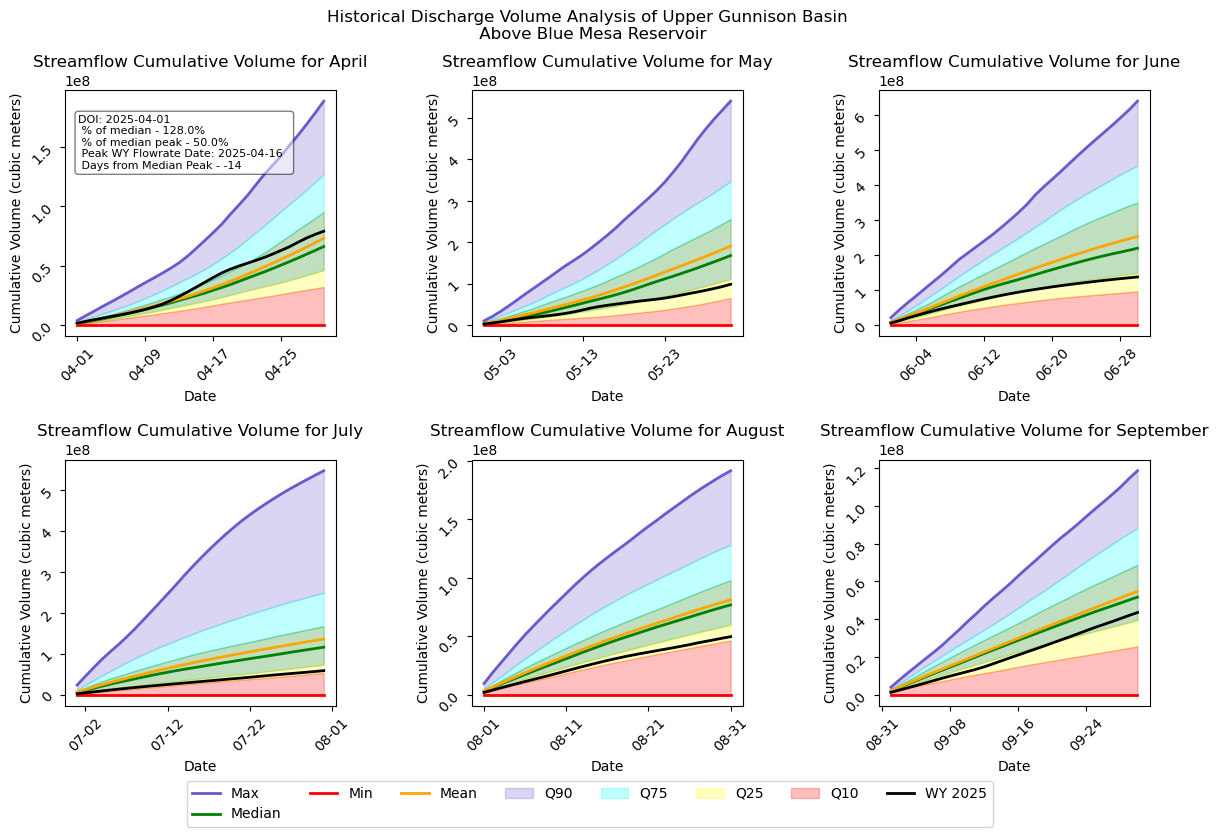

In [ ]:
stream_analysis.StreamPlots(processed, WY,watershed,AOI,DOI)

# 4. Peak Parity with Volumetric Streamflow April-September

The follwowing is a parity plot for April-September bewteen Peak SWE and monthly volumetric stremflow over each year. Because SWE and streamflow have vastly different cells, a line of best fit was used instead of the standard 45 degree line.  

As seen on the charts, the tighter clusters of June, July, and possibly August clearly indicate that SWE is strongly influential for predicting flow. However, the other months are pretty wide scatters, so other factors like rain or warming temperatures are having a larger effect. When looking over time, the lateryears seem to fall below trend more often, so the trendline is likely falling a bit. This could imply that there will be less SWE contributing to streamflow in te future months. When focusing on our target date, it is quite difficult to determine if we can use SWE to make a strong conclusion as it has the largest spread graph. However, if we were to focus on the previous years, the SWE seems to be higher with lower flow, showing that something is causing the snowpack to retain water for a long time. A further analysis and conclusion is found in the general report. 

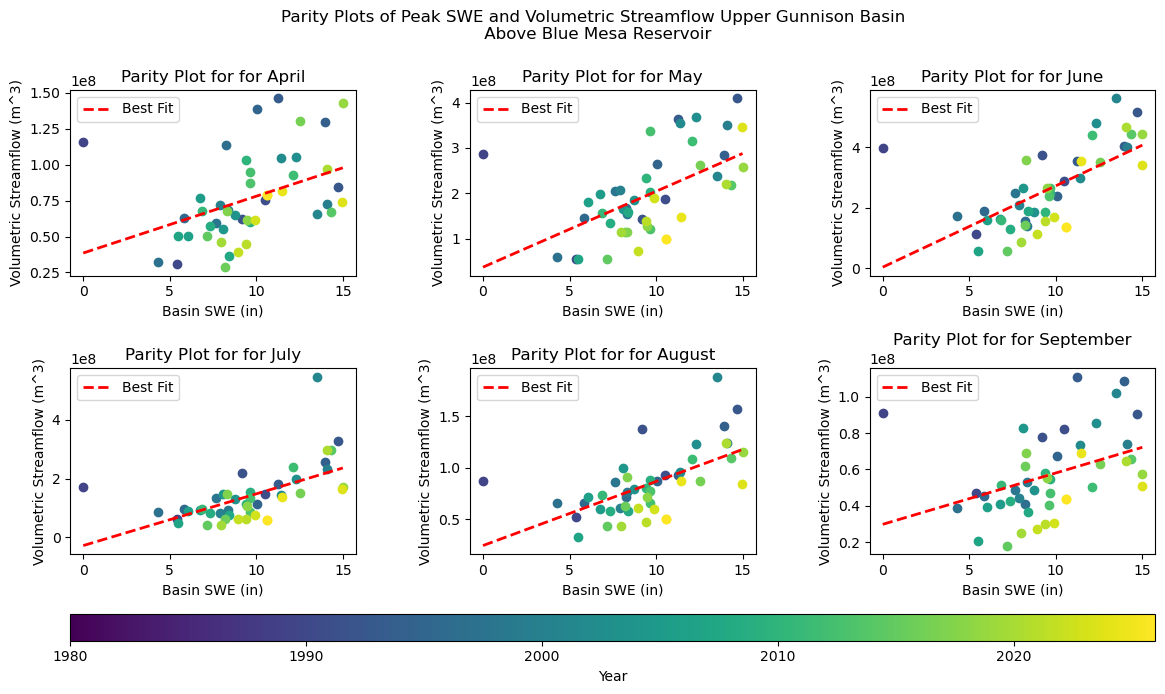

In [ ]:
peakswe = SWE_Stream.process_swe(sitedict)

SWE_Stream.Parity_Plot(peakswe,processed,watershed,AOI)